# 复现 Fig. 2：Ludlow16 与 Prada12 浓度演化比较

Fig. 2 比较两种浓度模型下四类暗物质晕的 $C[M(z),z]$。主体模块 `haloconcentration.py` 只提供浓度与质量吸积公式，本 Notebook 负责：

- 选择 $M_0=10^3,10^6,10^9,10^{12} M_\odot$；
- 分别建立 Ludlow16、旧 Prada12 和新 Prada12-HMF-σ 的质量与浓度轨迹；
- 保留原来的上下两个面板，并为新 Prada12 单独绘制论文 Fig. 2 bottom 风格图；
- 新 Prada12 的 $C(M_0,0)$ 会重新进入 Appendix C，计算新的 $z_{-2}$、$\alpha$、$\beta$ 和 $M(z)$。

## 1. 导入模块并定位项目目录

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "haloconcentration.py").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import haloconcentration as hc

PROJECT_ROOT

WindowsPath('D:/pbh formation/pbh merge/2body channel and numerical simulation')

## 2. 设置 Fig. 2 参数

Fig. 2 的横轴是线性红移，因此可以包含 $z=0$。四条曲线分别代表四个今天质量 $M_0$，计算过程中每条曲线始终保留自己的 $M_0$ 身份。

In [2]:
REDSHIFT = np.linspace(0.0, 12.0, 401)
PRESENT_DAY_MASSES_MSUN = np.array([1.0e3, 1.0e6, 1.0e9, 1.0e12])
LINE_STYLES = ["-", "--", "-.", ":"]
OUTPUT_TAG = "(1)"

PRESENT_DAY_MASSES_MSUN

array([1.e+03, 1.e+06, 1.e+09, 1.e+12])

## 3. 定义 Fig. 2 的数据组织函数

这个函数属于 Fig. 2 的具体数据组织，所以从主体 `.py` 文件移到了 Notebook。对每个 $M_0$，它先用相应模型计算 $M(z)$，再计算 $C[M(z),z]$。

两个 Prada12 分支都使用 `cap_prada=True`：当轨迹进入高峰高的 U 形上翘分支时，把浓度限制在该红移的最低浓度。这是项目复现论文 Fig. 2 平台趋势所采用的明确约定。

In [3]:
def figure2_model_data(redshift, model):
    mass_tracks = []
    concentration_tracks = []

    for mass0_msun in PRESENT_DAY_MASSES_MSUN:
        mass_track = hc.mass_accretion_history(
            mass0_msun,
            redshift,
            model,
        )
        concentration_track = hc.concentration_model(
            mass_track,
            redshift,
            model,
            cap_prada=model.lower().startswith("prada12"),
        )
        mass_tracks.append(mass_track)
        concentration_tracks.append(concentration_track)

    return np.asarray(mass_tracks), np.asarray(concentration_tracks)

## 4. 计算三种模型的轨迹

每个返回数组的形状都是 `(4, 401)`：4 行对应四个 $M_0$，401 列对应红移网格。

In [4]:
ludlow_mass_tracks, ludlow_concentration_tracks = figure2_model_data(
    REDSHIFT,
    model="ludlow16",
)
prada_mass_tracks, prada_concentration_tracks = figure2_model_data(
    REDSHIFT,
    model="prada12",
)
prada_hmf_mass_tracks, prada_hmf_concentration_tracks = (
    figure2_model_data(
        REDSHIFT,
        model="prada12_hmf_sigma",
    )
)

old_prada_mah_parameters = np.asarray([
    hc.mass_accretion_parameters(mass, "prada12")
    for mass in PRESENT_DAY_MASSES_MSUN
])
new_prada_mah_parameters = np.asarray([
    hc.mass_accretion_parameters(mass, "prada12_hmf_sigma")
    for mass in PRESENT_DAY_MASSES_MSUN
])

print("Ludlow16 数组形状：", ludlow_concentration_tracks.shape)
print("Prada12 数组形状：", prada_concentration_tracks.shape)
print("Prada12-HMF-σ 数组形状：", prada_hmf_concentration_tracks.shape)
print("列：M0, old z_-2, old alpha, old beta, new z_-2, new alpha, new beta")
print(np.column_stack([
    PRESENT_DAY_MASSES_MSUN,
    old_prada_mah_parameters,
    new_prada_mah_parameters,
]))

# 展示四类晕在 z=0 时的浓度，作为人工阅读起点。
np.column_stack([
    PRESENT_DAY_MASSES_MSUN,
    ludlow_concentration_tracks[:, 0],
    prada_concentration_tracks[:, 0],
    prada_hmf_concentration_tracks[:, 0],
])

Ludlow16 数组形状： (4, 401)
Prada12 数组形状： (4, 401)
Prada12-HMF-σ 数组形状： (4, 401)
列：M0, old z_-2, old alpha, old beta, new z_-2, new alpha, new beta
[[ 1.00000000e+03  1.36156374e+01  6.80179949e-02 -2.05259608e-01
   1.15664921e+01  8.39518786e-02 -2.38730107e-01]
 [ 1.00000000e+06  8.43844886e+00  1.18133474e-01 -3.17848838e-01
   8.37645623e+00  1.18985507e-01 -3.19950302e-01]
 [ 1.00000000e+09  5.21409256e+00  1.78244322e-01 -4.82773627e-01
   5.47079712e+00  1.71889765e-01 -4.63621397e-01]
 [ 1.00000000e+12  3.03767581e+00  2.50695960e-01 -7.43001703e-01
   3.06127196e+00  2.49703934e-01 -7.38684832e-01]]


array([[1.00000000e+03, 2.49977653e+01, 3.58007844e+01, 3.01414583e+01],
       [1.00000000e+06, 1.97797161e+01, 2.16788356e+01, 2.15137198e+01],
       [1.00000000e+09, 1.43767616e+01, 1.32753536e+01, 1.39279457e+01],
       [1.00000000e+12, 8.71030918e+00, 7.92172758e+00, 7.97747642e+00]])

## 5. 使用新 Prada12-HMF-σ 绘制论文 Fig. 2 bottom

这一幅图不是把新浓度套到旧质量轨迹上。`model="prada12_hmf_sigma"` 会先用新模型计算 $C(M_0,0)$，再由 Appendix C 重新得到 $z_{-2}$、$\alpha$、$\beta$ 和整条 $M(z)$，最后计算 $C[M(z),z]$。

新 Prada12 bottom 图已保存：D:\pbh formation\pbh merge\2body channel and numerical simulation\fig2_prada12_hmf_sigma(1).png


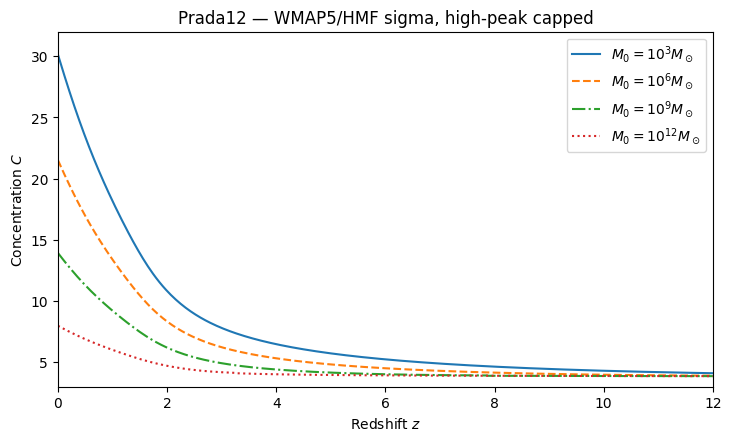

In [5]:
new_prada_figure, new_prada_axis = plt.subplots(
    figsize=(7.2, 4.3),
    constrained_layout=True,
)
for index, mass0_msun in enumerate(PRESENT_DAY_MASSES_MSUN):
    exponent = int(np.log10(mass0_msun))
    label = rf"$M_0=10^{{{exponent}}} M_\odot$"
    new_prada_axis.plot(
        REDSHIFT,
        prada_hmf_concentration_tracks[index],
        linestyle=LINE_STYLES[index],
        label=label,
    )

new_prada_axis.set_title("Prada12 — WMAP5/HMF sigma, high-peak capped")
new_prada_axis.set_xlim(0.0, 12.0)
new_prada_axis.set_ylim(3.0, 32.0)
new_prada_axis.set_xlabel(r"Redshift $z$")
new_prada_axis.set_ylabel(r"Concentration $C$")
new_prada_axis.legend(loc="upper right")

new_prada_figure_path = (
    PROJECT_ROOT / f"fig2_prada12_hmf_sigma{OUTPUT_TAG}.png"
)
new_prada_figure.savefig(new_prada_figure_path, dpi=220)
print(f"新 Prada12 bottom 图已保存：{new_prada_figure_path}")
plt.show()

## 5.1 保留 Ludlow16 与旧 Prada12 的上下对照图

图片已保存：D:\pbh formation\pbh merge\2body channel and numerical simulation\fig2_reproduction(1).png


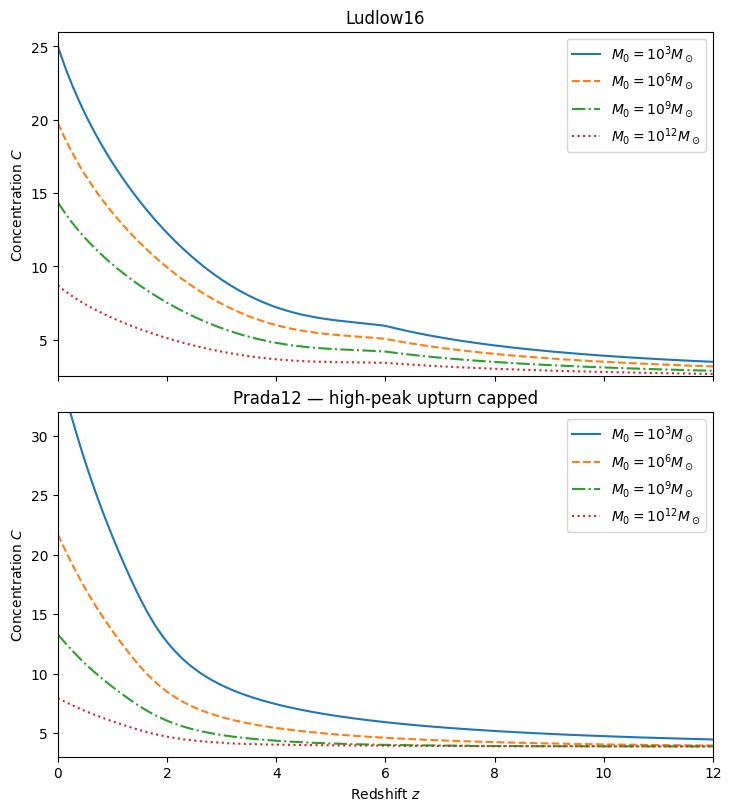

In [6]:
figure, axes = plt.subplots(
    2,
    1,
    figsize=(7.2, 8.0),
    sharex=True,
    constrained_layout=True,
)

for index, mass0_msun in enumerate(PRESENT_DAY_MASSES_MSUN):
    exponent = int(np.log10(mass0_msun))
    label = rf"$M_0=10^{{{exponent}}} M_\odot$"
    axes[0].plot(
        REDSHIFT,
        ludlow_concentration_tracks[index],
        linestyle=LINE_STYLES[index],
        label=label,
    )
    axes[1].plot(
        REDSHIFT,
        prada_concentration_tracks[index],
        linestyle=LINE_STYLES[index],
        label=label,
    )

axes[0].set_title("Ludlow16")
axes[1].set_title("Prada12 — high-peak upturn capped")
axes[0].set_ylim(2.5, 26.0)
axes[1].set_ylim(3.0, 32.0)

for axis in axes:
    axis.set_xlim(0.0, 12.0)
    axis.set_ylabel(r"Concentration $C$")
    axis.legend(loc="upper right")

axes[1].set_xlabel(r"Redshift $z$")

figure_path = PROJECT_ROOT / f"fig2_reproduction{OUTPUT_TAG}.png"
figure.savefig(figure_path, dpi=220)
print(f"图片已保存：{figure_path}")
plt.show()

## 6. 分别导出 Ludlow16、旧 Prada12 和新 Prada12 数据

每份 CSV 的第一列是红移，随后四列是质量轨迹，最后四列是相应浓度轨迹。

In [7]:
ludlow_table = np.column_stack([
    REDSHIFT,
    ludlow_mass_tracks.T,
    ludlow_concentration_tracks.T,
])
prada_table = np.column_stack([
    REDSHIFT,
    prada_mass_tracks.T,
    prada_concentration_tracks.T,
])
prada_hmf_table = np.column_stack([
    REDSHIFT,
    prada_hmf_mass_tracks.T,
    prada_hmf_concentration_tracks.T,
])

mass_columns = [
    f"mass_track_M0_{mass:.0e}_msun"
    for mass in PRESENT_DAY_MASSES_MSUN
]
concentration_columns = [
    f"concentration_M0_{mass:.0e}"
    for mass in PRESENT_DAY_MASSES_MSUN
]
header = ",".join(["z", *mass_columns, *concentration_columns])

ludlow_csv_path = PROJECT_ROOT / f"fig2_ludlow16{OUTPUT_TAG}.csv"
prada_csv_path = PROJECT_ROOT / f"fig2_prada12{OUTPUT_TAG}.csv"
prada_hmf_csv_path = (
    PROJECT_ROOT / f"fig2_prada12_hmf_sigma{OUTPUT_TAG}.csv"
)

np.savetxt(
    ludlow_csv_path,
    ludlow_table,
    delimiter=",",
    header=header,
    comments="",
)
np.savetxt(
    prada_csv_path,
    prada_table,
    delimiter=",",
    header=header,
    comments="",
)
np.savetxt(
    prada_hmf_csv_path,
    prada_hmf_table,
    delimiter=",",
    header=header,
    comments="",
)

print(f"Ludlow16 数据已保存：{ludlow_csv_path}")
print(f"Prada12 数据已保存：{prada_csv_path}")
print(f"新 Prada12 数据已保存：{prada_hmf_csv_path}")

Ludlow16 数据已保存：D:\pbh formation\pbh merge\2body channel and numerical simulation\fig2_ludlow16(1).csv
Prada12 数据已保存：D:\pbh formation\pbh merge\2body channel and numerical simulation\fig2_prada12(1).csv
新 Prada12 数据已保存：D:\pbh formation\pbh merge\2body channel and numerical simulation\fig2_prada12_hmf_sigma(1).csv


## 7. 输出少量人工对照值

这些数值只用于学习时人工核对，不进行自动判定，也不构成自检模块。

In [8]:
print(f"Ludlow nu0(z=0) = {float(hc.ludlow_nu0(0.0)):.6f}")
print(f"Prada x(z=0) = {float(hc.prada_time_variable(0.0)):.6f}")
print(
    "Prada D(z=0), normalized = "
    f"{float(hc.growth_factor_prada12(0.0)):.6f}"
)

Ludlow nu0(z=0) = 3.413220
Prada x(z=0) = 1.393113
Prada D(z=0), normalized = 1.000000
